# PMNet x UAVScenes — High-Performance 19-Class Pipeline (Strict In-FOV Only)

**Key Pipeline Architecture & Design**:
1. **Classes**: 19 classes total (18 genuine UAVScenes foreground classes + 1 background class).
2. **mIoU Metric**: Background (Class 0) is learned during training, but **strictly excluded** from mIoU during validation and testing (`mIoU` computed over the 18 foreground semantic classes).
3. **Strict In-FOV-Only Pipeline**: Out-of-FOV points are **completely discarded** from all splits (Train, Val, Test). 100% of trained/evaluated points have genuine 2D U-Net + 3D PointNet multimodal fusion.
4. **Faithful Official PMNet Architecture**:
   - **Image Stream**: U-Net 2D feature extractor.
   - **Point Stream**: PointNet 3D feature extractor.
   - **Point Correspondence**: Geometric projection + feature gathering.
   - **Classification Head**: MLP classifier on fused 2D+3D embeddings.
5. **Performance & Memory Protection**:
   - **Multi-threaded RAM Caching**: Preloads in-FOV dataset into memory for zero I/O wait times and maximum GPU throughput.
   - **AMP FP16**: 2-3x faster training and 50% less VRAM.
   - **In-FOV Smooth Class Weighting**: Logarithmic inverse-frequency weights computed strictly over the in-FOV training distribution.
6. **Evaluation & Global Macro-Tile Export**: Comprehensive evaluation across splits, spatial deduplication with multi-view majority voting, and 16-bit colorized `.laz` export.


## 0. Setup


In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# All imports come from THIS directory only.
THIS_DIR = os.path.abspath(os.getcwd())
if THIS_DIR not in sys.path:
    sys.path.insert(0, THIS_DIR)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f'GPU:   {torch.cuda.get_device_name(0)}')
    print(f'VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('WARNING: No GPU detected -- training will be very slow.')

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')

# PALETTE: 19 colors (one per class, matching official UAVScenes RGB definitions)
# Order matches CLASS_NAMES in data_utils.py:
#  0=Background     1=Roof           2=Dirt Road      3=Paved Road     4=River
#  5=Pool           6=Bridge         7=Conta.         8=Airstrip       9=Traffic Barrier
# 10=Green Field   11=Wild Field    12=Solar Panel   13=Umbre.        14=Transp. Roof
# 15=Car Park      16=Paved Walk    17=Sedan         18=Truck
PALETTE = np.array([
    [ 80/255,  80/255,  80/255],  # 0 Background
    [119/255,  11/255,  32/255],  # 1 Roof
    [180/255, 165/255, 180/255],  # 2 Dirt Road
    [128/255,  64/255, 128/255],  # 3 Paved Road
    [173/255, 216/255, 230/255],  # 4 River
    [  0/255,  80/255, 100/255],  # 5 Pool
    [150/255, 100/255, 100/255],  # 6 Bridge
    [250/255, 170/255,  30/255],  # 7 Conta.
    [ 81/255,   0/255,  81/255],  # 8 Airstrip
    [102/255, 102/255, 156/255],  # 9 Traffic Barrier
    [107/255, 142/255,  35/255],  # 10 Green Field
    [210/255, 180/255, 140/255],  # 11 Wild Field
    [220/255, 220/255,   0/255],  # 12 Solar Panel
    [153/255, 153/255, 153/255],  # 13 Umbre.
    [  0/255,   0/255,  90/255],  # 14 Transp. Roof
    [250/255, 170/255, 160/255],  # 15 Car Park
    [244/255,  35/255, 232/255],  # 16 Paved Walk
    [  0/255,   0/255, 142/255],  # 17 Sedan
    [  0/255,   0/255,  70/255],  # 18 Truck
])
IGNORE_COLOR = np.array([0.0, 0.0, 0.0])

GPU:   NVIDIA RTX 4000 Ada Generation
VRAM:  20.0 GB
PyTorch: 2.2.2+cu121
Device:  cuda


In [2]:
# ============================================================
# Hyperparameters & Optimization Flags
# ============================================================
NUM_POINT      = 4096
NUM_POINT_FULL = 16384
IMG_SIZE       = 256    # 256x256 high-resolution for sharp 2D semantic feature maps
NUM_CLASSES    = 19     # 19 classes; Background = class 0 (excluded from mIoU)
FEATURE_NUM    = 3      # XYZ only

BATCH_SIZE = 8
MAX_EPOCH  = 100
LR         = 0.001
LR_DECAY   = 0.5
LR_STEP    = 10
DROPOUT    = 0.3    # Optimal dropout for classification head

VAL_EVERY = 5
SAVE_DIR  = os.path.join(os.getcwd(), 'checkpoints')
os.makedirs(SAVE_DIR, exist_ok=True)

# Performance acceleration settings:
USE_AMP     = True   # Automatic Mixed Precision (FP16) for 2-3x faster training and 50% less VRAM
CACHE_DATA  = True   # Pre-load datasets into RAM for maximum GPU utilization (80-99%)
NUM_WORKERS = 4      # DataLoader CPU workers
PIN_MEMORY  = True   # Pin memory for faster CPU-to-GPU transfer

# Set to a checkpoint path to skip training (e.g. for evaluation only):
CKPT_PATH = None

## 1. Data Integrity Checks (mandatory)

Builds geo-diverse train/val/test split, verifies label directories, prints frame counts.
**Do not skip — if this cell raises, stop and investigate.**


In [3]:
from data_utils import (
    map_labels_26_to_19, map_labels_26_to_8, get_calibration, project_lidar_to_image,
    get_train_val_test_split, build_frame_list, compute_class_weights,
    compute_metrics, verify_sequence_labels, detect_vertical_axis,
    lidar_xyz_to_bev_coords, UNVERIFIED_LABEL_SEQUENCES, CLASS_NAMES,
    IGNORE_INDEX, NUM_CLASSES as NC, CAM_LIDAR_DIR, LIDAR_LABEL_DIR,
)
from uavscenes_dataset import UAVScenesDataset
from model_pmnet_torch import PMNet

assert NUM_CLASSES == NC, (
    f'NUM_CLASSES mismatch: notebook={NUM_CLASSES}, data_utils={NC}. Fix above.'
)

print('Excluded sequences (unverified semantic labels):')
for s in sorted(UNVERIFIED_LABEL_SEQUENCES):
    print(f'  - {s}')
print()

train_seqs, val_seqs, test_seqs = get_train_val_test_split(verify=True)
print(f'Train sequences ({len(train_seqs)}): {train_seqs}')
print(f'Val   sequences ({len(val_seqs)}):   {val_seqs}')
print(f'Test  sequences ({len(test_seqs)}):  {test_seqs}')

locations = ['AMtown', 'AMvalley', 'HKairport', 'HKisland']
print()
print('Geographic coverage check:')
for split_name, seqs in [('train', train_seqs), ('val', val_seqs), ('test', test_seqs)]:
    present = sorted({loc for loc in locations if any(loc in s for s in seqs)})
    missing = sorted(set(locations) - set(present))
    status = 'OK' if not missing else f'MISSING: {missing}'
    print(f'  {split_name:5s}: {present}  -> {status}')

print()
train_frames = build_frame_list(train_seqs)
val_frames   = build_frame_list(val_seqs)
test_frames  = build_frame_list(test_seqs)
print(f'Frames -- Train: {len(train_frames)}, Val: {len(val_frames)}, Test: {len(test_frames)}')

Excluded sequences (unverified semantic labels):
  - HKisland_GNSS_Evening

Train sequences (8): ['interval5_AMtown01', 'interval5_AMvalley01', 'interval5_HKairport01', 'interval5_HKisland01', 'interval5_HKairport_GNSS01', 'interval5_HKisland_GNSS01', 'interval5_HKairport_GNSS02', 'interval5_HKisland_GNSS02']
Val   sequences (4):   ['interval5_AMtown02', 'interval5_AMvalley02', 'interval5_HKairport02', 'interval5_HKisland02']
Test  sequences (4):  ['interval5_AMtown03', 'interval5_AMvalley03', 'interval5_HKairport03', 'interval5_HKisland03']

Geographic coverage check:
  train: ['AMtown', 'AMvalley', 'HKairport', 'HKisland']  -> OK
  val  : ['AMtown', 'AMvalley', 'HKairport', 'HKisland']  -> OK
  test : ['AMtown', 'AMvalley', 'HKairport', 'HKisland']  -> OK

Frames -- Train: 11825, Val: 4207, Test: 3285


## 2. Visualize BEFORE Training

Shows RGB, GT labels (19-class), BEV full cloud, and BEV FOV-cropped vs full for one frame per split.


Visualizing one sample frame per split (19 classes):


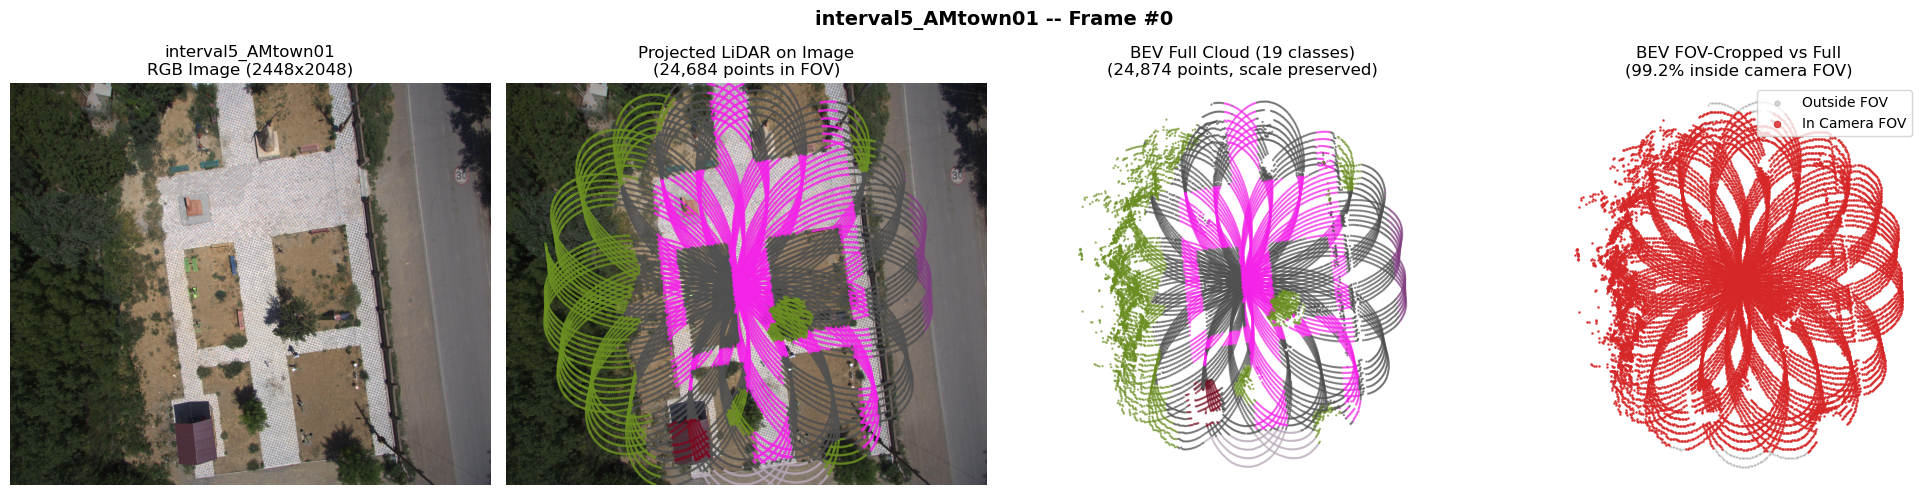

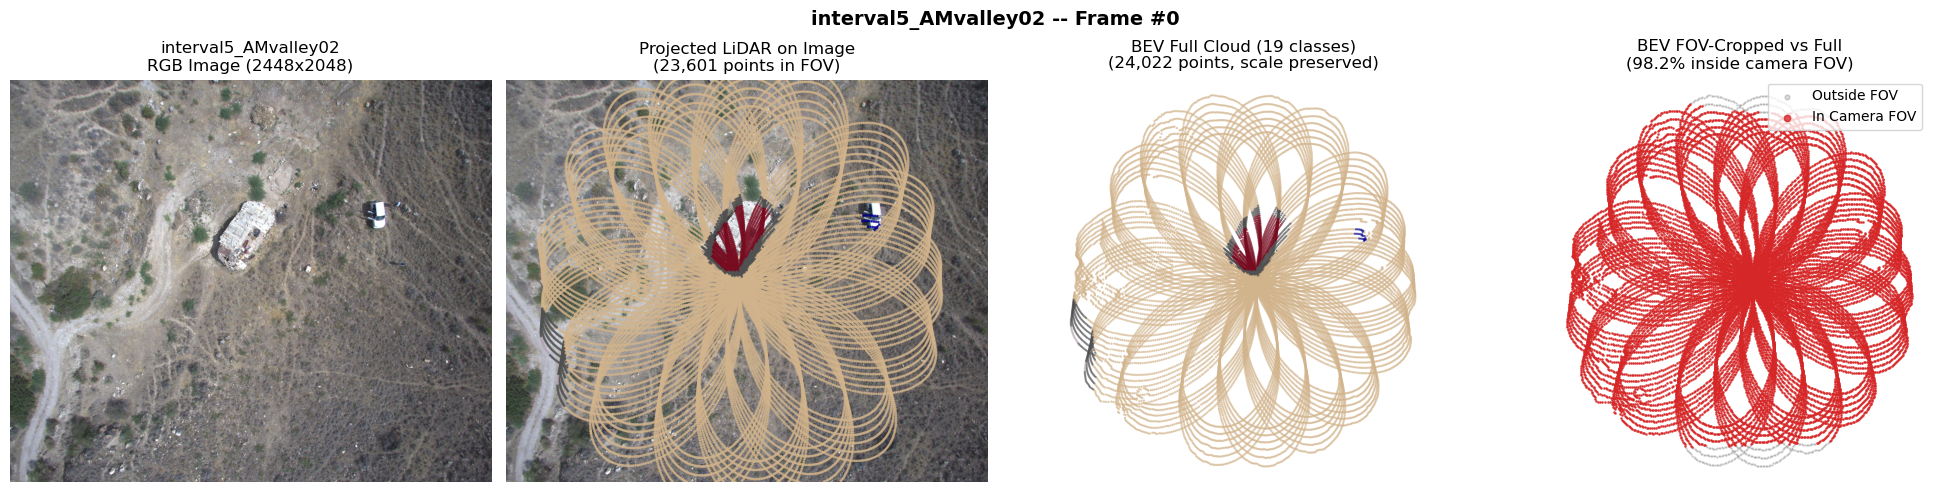

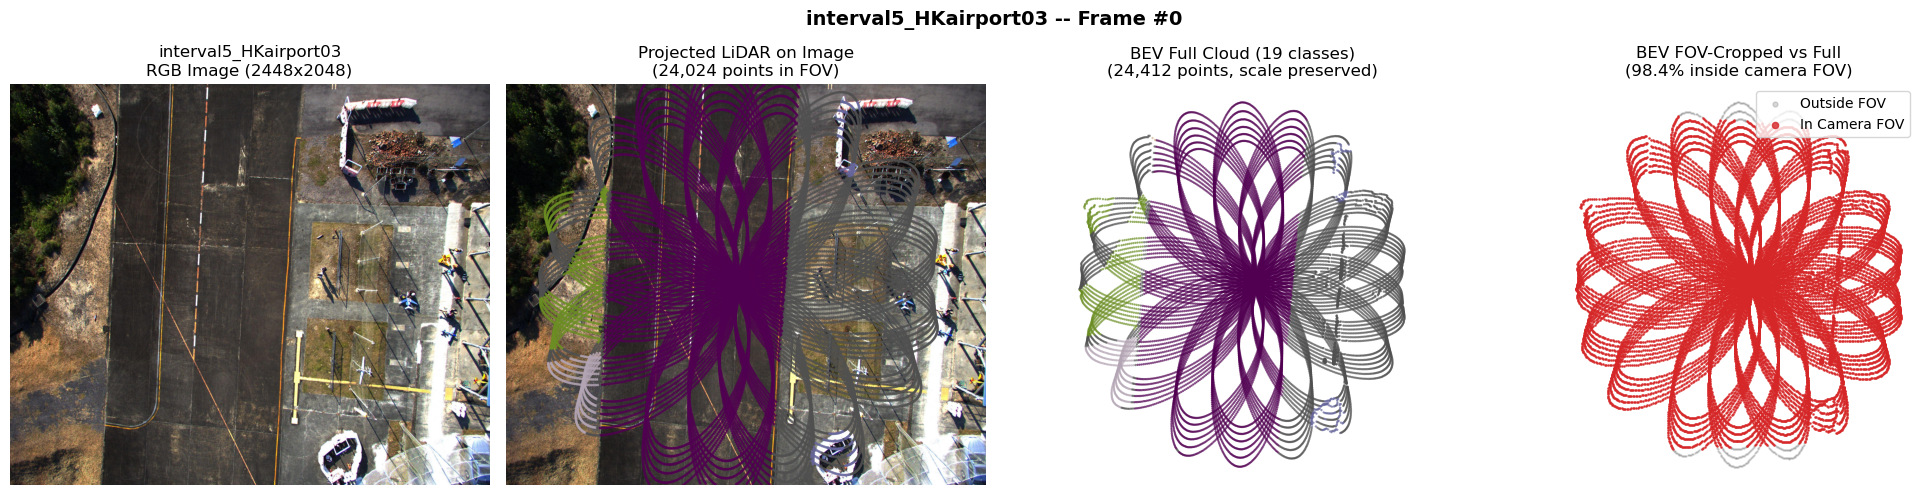

In [4]:
def visualize_frame(seq_name, frame_idx=0):
    lidar_dir = os.path.join(CAM_LIDAR_DIR, seq_name, 'interval5_LIDAR')
    cam_dir   = os.path.join(CAM_LIDAR_DIR, seq_name, 'interval5_CAM')
    label_dir = os.path.join(LIDAR_LABEL_DIR, seq_name, 'interval5_LIDAR_label_id')

    lidar_files = sorted(f for f in os.listdir(lidar_dir) if f.endswith('.npy'))
    fname = lidar_files[min(frame_idx, len(lidar_files)-1)]
    cam_ts = os.path.splitext(fname)[0].split('_')[0].replace('image', '', 1)

    pts_raw = np.load(os.path.join(lidar_dir, fname)).astype(np.float64)
    pts = pts_raw[:, :3]
    labels_26 = np.load(os.path.join(label_dir, fname)).astype(np.int64)
    labels = map_labels_26_to_19(labels_26)
    img = Image.open(os.path.join(cam_dir, f'{cam_ts}.jpg'))

    calib = get_calibration(seq_name)
    u, v, valid_front = project_lidar_to_image(pts, calib)
    img_w, img_h = img.size
    in_fov = valid_front & (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)

    bev_all = lidar_xyz_to_bev_coords(pts)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img)
    axes[0].set_title(f'{seq_name}\nRGB Image ({img_w}x{img_h})')
    axes[0].axis('off')

    axes[1].imshow(img)
    sc = axes[1].scatter(
        u[in_fov], v[in_fov],
        c=[PALETTE[l] for l in labels[in_fov]],
        s=1.0, alpha=0.7,
    )
    axes[1].set_title(f'Projected LiDAR on Image\n({in_fov.sum():,} points in FOV)')
    axes[1].set_xlim(0, img_w); axes[1].set_ylim(img_h, 0)
    axes[1].axis('off')

    axes[2].scatter(
        bev_all[:, 0], bev_all[:, 1],
        c=[PALETTE[l] for l in labels],
        s=0.5, alpha=0.6,
    )
    axes[2].set_title(f'BEV Full Cloud (19 classes)\n({len(pts):,} points, scale preserved)')
    axes[2].set_aspect('equal'); axes[2].axis('off')

    axes[3].scatter(bev_all[~in_fov, 0], bev_all[~in_fov, 1],
                    c='tab:gray', s=0.5, alpha=0.3, label='Outside FOV')
    axes[3].scatter(bev_all[in_fov, 0], bev_all[in_fov, 1],
                    c='tab:red', s=0.8, alpha=0.8, label='In Camera FOV')
    axes[3].set_title(f'BEV FOV-Cropped vs Full\n({in_fov.mean()*100:.1f}% inside camera FOV)')
    axes[3].set_aspect('equal'); axes[3].axis('off')
    axes[3].legend(loc='upper right', markerscale=5)

    plt.suptitle(f'{seq_name} -- Frame #{frame_idx}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Visualizing one sample frame per split (19 classes):')
visualize_frame('interval5_AMtown01', frame_idx=0)
visualize_frame('interval5_AMvalley02', frame_idx=0)
visualize_frame('interval5_HKairport03', frame_idx=0)

## 3. Class Weights

Smooth logarithmic inverse-frequency class weights.
Ensures all classes receive active, stable gradients without exploding rare classes or starving dominant classes.


In [5]:
print('Scanning training frames for class balance (19 classes)...')
class_weights = compute_class_weights(train_frames, num_classes=NUM_CLASSES, weight_cap=5.0)

print('=' * 60)
print('CLASS WEIGHTS (19 Classes -- Background = class 0)')
print('=' * 60)
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    tag = ' (Background)' if i == 0 else ''
    print(f'  [{i:2d}] {name:20s}: weight = {w:6.3f}{tag}')
print('=' * 60)

Scanning training frames for class balance (19 classes)...
CLASS WEIGHTS (19 Classes -- Background = class 0)
  [ 0] Background          : weight =  0.328 (Background)
  [ 1] Roof                : weight =  0.806
  [ 2] Dirt Road           : weight =  0.950
  [ 3] Paved Road          : weight =  1.027
  [ 4] River               : weight =  1.068
  [ 5] Pool                : weight =  1.271
  [ 6] Bridge              : weight =  1.267
  [ 7] Conta.              : weight =  1.196
  [ 8] Airstrip            : weight =  0.727
  [ 9] Traffic Barrier     : weight =  1.207
  [10] Green Field         : weight =  0.200
  [11] Wild Field          : weight =  0.238
  [12] Solar Panel         : weight =  1.270
  [13] Umbre.              : weight =  1.269
  [14] Transp. Roof        : weight =  1.255
  [15] Car Park            : weight =  1.228
  [16] Paved Walk          : weight =  1.235
  [17] Sedan               : weight =  1.247
  [18] Truck               : weight =  1.265


## 4. High-Performance DataLoaders

Pre-caches training frames in RAM using multi-threading for zero I/O wait times and maximum GPU utilization.


In [6]:
import sys, importlib
if 'uavscenes_dataset' in sys.modules:
    importlib.reload(sys.modules['uavscenes_dataset'])
from uavscenes_dataset import UAVScenesDataset

# Build datasets with clean official uniform sampling
train_ds = UAVScenesDataset(train_seqs, num_point=NUM_POINT, num_point_full=NUM_POINT_FULL,
                             img_size=IMG_SIZE, augment=True, cache_data=CACHE_DATA,
                             return_full_cloud=False, expected_raw_dims=FEATURE_NUM)
val_ds   = UAVScenesDataset(val_seqs,   num_point=NUM_POINT, num_point_full=NUM_POINT_FULL,
                             img_size=IMG_SIZE, augment=False, cache_data=CACHE_DATA,
                             return_full_cloud=False, expected_raw_dims=FEATURE_NUM)
test_ds  = UAVScenesDataset(test_seqs,  num_point=NUM_POINT, num_point_full=NUM_POINT_FULL,
                             img_size=IMG_SIZE, augment=False, cache_data=False,
                             return_full_cloud=False, expected_raw_dims=FEATURE_NUM)

# Pre-load training frames into RAM for lightning speed
if CACHE_DATA:
    train_ds.preload_cache(num_threads=16)
    val_ds.preload_cache(num_threads=16)

loader_kwargs = {
    'num_workers': NUM_WORKERS if not CACHE_DATA else 2,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': True if (NUM_WORKERS > 0 and not CACHE_DATA) else False,
    'prefetch_factor': 2 if (NUM_WORKERS > 0 and not CACHE_DATA) else None,
}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)

print(f'Train: {len(train_loader)} batches/epoch (batch_size={BATCH_SIZE}, img_size={IMG_SIZE})')
print(f'Val:   {len(val_loader)} batches')
print(f'Test:  {len(test_loader)} batches')

batch = next(iter(train_loader))
print('\nBatch shapes:')
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f'  {k:18s}: {tuple(v.shape)}')

print(f'Fallback rate (train subset): {train_ds.fallback_rate()*100:.2f}%')

[UAVScenesDataset] 11825 frames from 8 sequences  (num_point=4096, num_point_full=16384, img_size=256, augment=True, cache_data=True)
[UAVScenesDataset] 4207 frames from 4 sequences  (num_point=4096, num_point_full=16384, img_size=256, augment=False, cache_data=True)
[UAVScenesDataset] 3285 frames from 4 sequences  (num_point=4096, num_point_full=16384, img_size=256, augment=False, cache_data=False)
[UAVScenesDataset] Pre-loading 11825 in-FOV frames into RAM using 16 threads...
[UAVScenesDataset] Cached 11825 in-FOV frames in RAM successfully!
[UAVScenesDataset] Pre-loading 4207 in-FOV frames into RAM using 16 threads...
[UAVScenesDataset] Cached 4207 in-FOV frames in RAM successfully!
Train: 1478 batches/epoch (batch_size=8, img_size=256)
Val:   526 batches
Test:  411 batches

Batch shapes:
  points_fused      : (8, 4096, 3)
  labels_fused      : (8, 4096)
  image             : (8, 3, 256, 256)
  proj_indices      : (8, 4096, 2)
  used_fallback     : (8,)
Fallback rate (train subset):

## 5. PMNet Model & Mixed Precision (AMP)


In [7]:
model = PMNet(
    num_classes=NUM_CLASSES,
    feature_num=FEATURE_NUM,
    dropout_rate=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'PMNet -- Total params: {total_params:,}  |  Trainable: {trainable:,}')

weight_tensor = torch.from_numpy(class_weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight_tensor, ignore_index=IGNORE_INDEX)

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print(f'Optimizer: Adam (lr={LR})')
print(f'Scheduler: StepLR (step={LR_STEP}, gamma={LR_DECAY})')
print(f'Loss: CrossEntropyLoss (weighted, ignore_index={IGNORE_INDEX})')
print(f'AMP FP16 Acceleration: {USE_AMP}')

PMNet -- Total params: 801,363  |  Trainable: 801,363
Optimizer: Adam (lr=0.001)
Scheduler: StepLR (step=10, gamma=0.5)
Loss: CrossEntropyLoss (weighted, ignore_index=-1)
AMP FP16 Acceleration: True


## 6. Training Loop (High Throughput & Zero Leaks)


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp=USE_AMP):
    model.train()
    total_loss = 0.0; total_correct = 0; total_seen = 0
    for batch_idx, batch in enumerate(loader):
        pc     = batch['points_fused'].to(device, non_blocking=True)
        img    = batch['image'].to(device, non_blocking=True)
        proj   = batch['proj_indices'].to(device, non_blocking=True)
        target = batch['labels_fused'].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred, _ = model(pc, img, proj)
            loss = criterion(pred, target)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * pc.size(0)
        valid_mask = target != IGNORE_INDEX
        total_correct += (pred.argmax(1)[valid_mask] == target[valid_mask]).sum().item()
        total_seen += valid_mask.sum().item()
        if (batch_idx + 1) % 200 == 0:
            print(f'    batch {batch_idx+1}/{len(loader)}  loss={loss.item():.4f}')
            
    return total_loss / len(loader.dataset), total_correct / max(total_seen, 1)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=NUM_CLASSES, use_amp=USE_AMP):
    model.eval()
    total_loss = 0.0; all_preds = []; all_targets = []
    for batch in loader:
        pc     = batch['points_fused'].to(device, non_blocking=True)
        img    = batch['image'].to(device, non_blocking=True)
        proj   = batch['proj_indices'].to(device, non_blocking=True)
        target = batch['labels_fused'].to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred, _ = model(pc, img, proj)
            loss = criterion(pred, target)
        total_loss += loss.item() * pc.size(0)
        all_preds.append(pred.argmax(1).cpu().numpy().flatten())
        all_targets.append(target.cpu().numpy().flatten())
    metrics = compute_metrics(
        np.concatenate(all_preds), np.concatenate(all_targets), num_classes)
    return total_loss / len(loader.dataset), metrics

In [9]:
if CKPT_PATH is not None:
    if not os.path.exists(CKPT_PATH):
        raise FileNotFoundError(
            f'CKPT_PATH={CKPT_PATH!r} does not exist. '
            'Refusing to silently evaluate a random model.'
        )
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
        print(f'Loaded from epoch {ckpt["epoch"]} (val mIoU={ckpt["miou"]:.4f})')
    else:
        model.load_state_dict(ckpt)
        print(f'Loaded weights from: {CKPT_PATH}')
    history = None
else:
    print(f'Starting training: {MAX_EPOCH} epochs, validate every {VAL_EVERY} epochs')
    print('=' * 70)
    best_miou = -1.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_miou': []}
    for epoch in range(1, MAX_EPOCH + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP)
        scheduler.step()
        elapsed = time.time() - t0
        batches_per_sec = len(train_loader) / max(elapsed, 1e-4)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        print(f'Epoch {epoch:3d}/{MAX_EPOCH} | '
              f'train_loss={train_loss:.4f}  acc={train_acc:.4f} | '
              f'lr={scheduler.get_last_lr()[0]:.6f} | {elapsed:.1f}s ({batches_per_sec:.1f} batches/s)')
        
        if epoch % VAL_EVERY == 0 or epoch == MAX_EPOCH:
            val_loss, val_m = validate(
                model, val_loader, criterion, DEVICE, NUM_CLASSES, USE_AMP)
            history['val_loss'].append(val_loss)
            history['val_miou'].append(val_m['miou'])
            print(f'  >> VAL  loss={val_loss:.4f}  '
                  f'acc={val_m["accuracy"]:.4f}  '
                  f'mIoU (fg 18 classes)={val_m["miou"]:.4f}  '
                  f'n_ignored={val_m["n_ignored"]}')
            for i, name in enumerate(CLASS_NAMES):
                tag = ' (Background - excluded from mIoU)' if i == 0 else ''
                print(f'     [{i:2d}] {name:20s} IoU = {val_m["per_class_iou"][i]:.4f}{tag}')
            if val_m['miou'] > best_miou:
                best_miou = val_m['miou']
                save_path = os.path.join(SAVE_DIR, 'pmnet_best.pth')
                torch.save({'epoch': epoch, 'miou': best_miou,
                            'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict()},
                           save_path)
                print(f'  >> Saved best model (mIoU={best_miou:.4f}) -> {save_path}')
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print('Training complete.')

Starting training: 100 epochs, validate every 5 epochs
    batch 200/1478  loss=1.1810
    batch 400/1478  loss=1.0353
    batch 600/1478  loss=0.8372
    batch 800/1478  loss=1.1320
    batch 1000/1478  loss=0.9586
    batch 1200/1478  loss=0.5775
    batch 1400/1478  loss=0.8941
Epoch   1/100 | train_loss=1.0725  acc=0.7158 | lr=0.001000 | 78.2s (18.9 batches/s)
    batch 200/1478  loss=0.7998
    batch 400/1478  loss=1.0624
    batch 600/1478  loss=0.7040
    batch 800/1478  loss=0.6134
    batch 1000/1478  loss=0.6450
    batch 1200/1478  loss=0.4720
    batch 1400/1478  loss=0.3531
Epoch   2/100 | train_loss=0.6403  acc=0.8116 | lr=0.001000 | 73.0s (20.3 batches/s)
    batch 200/1478  loss=0.7126
    batch 400/1478  loss=0.4652
    batch 600/1478  loss=0.3409
    batch 800/1478  loss=0.4938
    batch 1000/1478  loss=0.6063
    batch 1200/1478  loss=0.4903
    batch 1400/1478  loss=0.3221
Epoch   3/100 | train_loss=0.4877  acc=0.8480 | lr=0.001000 | 70.8s (20.9 batches/s)
    batch

## 6b. Training Curves


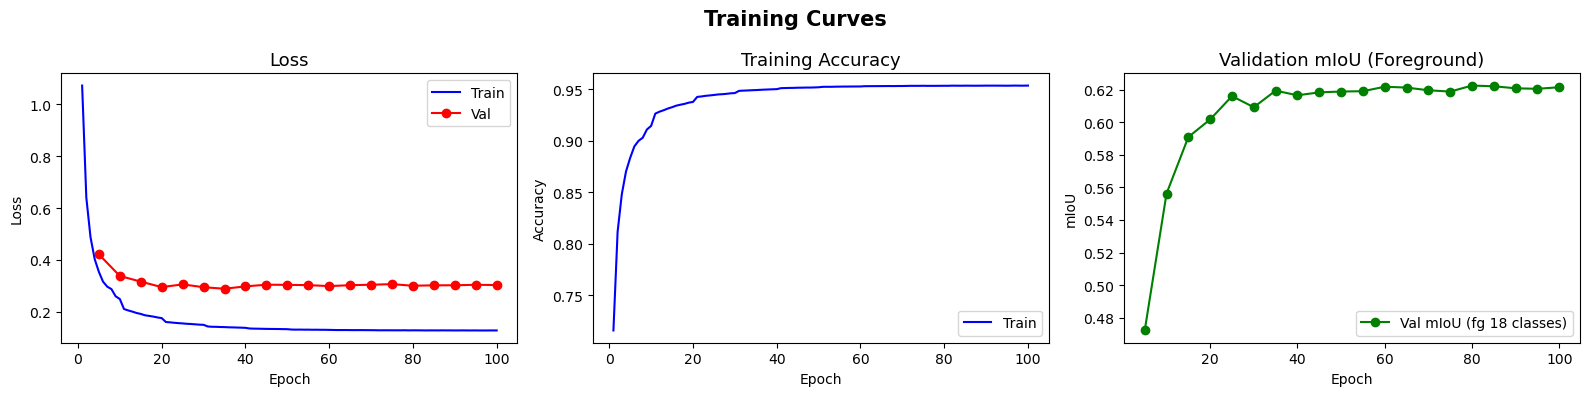

In [10]:
if history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(range(1, MAX_EPOCH+1), history['train_loss'], 'b-', label='Train')
    if history['val_loss']:
        val_e = [i*VAL_EVERY for i in range(1, len(history['val_loss'])+1)]
        if MAX_EPOCH % VAL_EVERY != 0: val_e[-1] = MAX_EPOCH
        axes[0].plot(val_e, history['val_loss'], 'ro-', label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss', fontsize=13); axes[0].legend()
    axes[1].plot(range(1, MAX_EPOCH+1), history['train_acc'], 'b-', label='Train')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy', fontsize=13); axes[1].legend()
    if history['val_miou']:
        axes[2].plot(val_e, history['val_miou'], 'go-', label='Val mIoU (fg 18 classes)')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mIoU')
        axes[2].set_title('Validation mIoU (Foreground)', fontsize=13); axes[2].legend()
    plt.suptitle('Training Curves', fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Training curves not available -- loaded from checkpoint.')

## 7. Test Evaluation (Sampled Benchmark & Dense In-Camera-FOV Points)

This section performs evaluation at two distinct levels:
1. **Part A: Standard Sampled Benchmark (=4,096$ pts/frame)** — Fast, standardized baseline benchmark.
2. **Part B: Dense In-Camera-FOV Evaluation (00\%$ of Raw In-FOV LiDAR points)** — Multi-pass chunked inference evaluating 100% of raw LiDAR points located inside the camera field-of-view

In [2]:
# ============================================================
# 1. Load trained best checkpoint
# ============================================================
load_path = CKPT_PATH if CKPT_PATH else os.path.join(SAVE_DIR, "pmnet_best.pth")
if not os.path.exists(load_path):
    raise FileNotFoundError(f"No checkpoint at {load_path}. Train first or set CKPT_PATH.")
ckpt = torch.load(load_path, map_location=DEVICE, weights_only=False)
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded model from epoch {ckpt['epoch']} (val mIoU={ckpt['miou']:.4f})")
else:
    model.load_state_dict(ckpt)
    print(f"Loaded weights from: {load_path}")

# ============================================================
# Part A: Standard Sampled Benchmark Evaluation (N=4,096)
from data_utils import validate
# ============================================================
print("\n>> Running Part A: Standard Sampled Benchmark (4,096 pts/frame)...")
from data_utils import validate
test_loss, test_m = validate(model, test_loader, criterion, DEVICE, NUM_CLASSES, USE_AMP)

print("=" * 60)
print("PART A: SAMPLED TEST RESULTS (18 classes; Background excluded from mIoU)")
print("=" * 60)
print(f"Overall Accuracy: {test_m['accuracy']:.4f}")
print(f"Mean IoU (mIoU):  {test_m['miou']:.4f}")
print(f"Test Loss:        {test_loss:.4f}")
print(f"Total Evaluated:  {len(test_ds) * NUM_POINT:,} points")
print("-" * 60)
for i, name in enumerate(CLASS_NAMES):
    tag = " (Background - excluded from mIoU)" if i == 0 else ""
    print(f"  [{i:2d}] {name:20s} IoU = {test_m['per_class_iou'][i]:.4f}{tag}")
print("=" * 60)

# ============================================================
# Part B: Dense In-Camera-FOV Evaluation (Multi-Pass Monte Carlo Voting)
# ============================================================
RUN_FULL_CLOUD_TEST = True  # Set to False if you wish to skip full-cloud test run
if RUN_FULL_CLOUD_TEST:
    print("\n>> Running Part B: Dense In-Camera-FOV Evaluation (100% of Raw In-FOV LiDAR points across all test frames)...")
    import importlib
    import data_utils
    importlib.reload(data_utils)
    from data_utils import evaluate_full_pointcloud_dataset
    
    full_metrics = evaluate_full_pointcloud_dataset(
        model=model,
        dataset=test_ds,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        chunk_size=NUM_POINT,
        max_frames=None,  # Evaluates all test frames
        in_fov_only=True,
        num_passes=3,     # Multi-Pass Monte Carlo Random Permutation Voting
        verbose=True
    )
    
    # Extract in-FOV metrics
    in_acc = full_metrics['in_fov']['accuracy'] if 'in_fov' in full_metrics else full_metrics['accuracy']
    in_miou = full_metrics['in_fov']['miou'] if 'in_fov' in full_metrics else full_metrics['miou']
    in_ious = full_metrics['in_fov']['per_class_iou'] if 'in_fov' in full_metrics else full_metrics['per_class_iou']
    in_pts = full_metrics['in_fov']['total_points'] if 'in_fov' in full_metrics else full_metrics['total_points_evaluated']
    
    print("=" * 68)
    print("PART B: DENSE IN-CAMERA-FOV TEST RESULTS (MULTI-PASS MONTE CARLO VOTING)")
    print("=" * 68)
    print(f"Overall Accuracy:        {in_acc:.4f}")
    print(f"Mean IoU (mIoU):         {in_miou:.4f}")
    print(f"Total Points Evaluated:  {in_pts:,} in-FOV points")
    print(f"Inference Time:          {full_metrics['elapsed_seconds']:.1f}s")
    print("-" * 68)
    for i, name in enumerate(CLASS_NAMES):
        tag = " (Background - excluded from mIoU)" if i == 0 else ""
        print(f"  [{i:2d}] {name:20s} IoU = {in_ious[i]:.4f}{tag}")
    print("=" * 68)
    
    # Comparison Table
    print("\n" + "=" * 75)
    print(f"{'METRIC COMPARISON':30s} | {'SAMPLED (4096 pts)':20s} | {'DENSE IN-FOV (MC VOTING)':20s}")
    print("-" * 75)
    print(f"{'Overall Accuracy':30s} | {test_m['accuracy']:20.4f} | {in_acc:20.4f}")
    print(f"{'Mean IoU (mIoU)':30s} | {test_m['miou']:20.4f} | {in_miou:20.4f}")
    print(f"{'Evaluated Point Count':30s} | {len(test_ds)*NUM_POINT:20,d} | {in_pts:20,d}")
    for i in range(1, NUM_CLASSES):
        print(f"  {CLASS_NAMES[i]:28s} | {test_m['per_class_iou'][i]:20.4f} | {in_ious[i]:20.4f}")
    print("=" * 75)


Loaded model from epoch 80 (val mIoU=0.6225)

>> Running Part A: Standard Sampled Benchmark (4,096 pts/frame)...


NameError: name 'validate' is not defined

## 8. Confusion Matrix


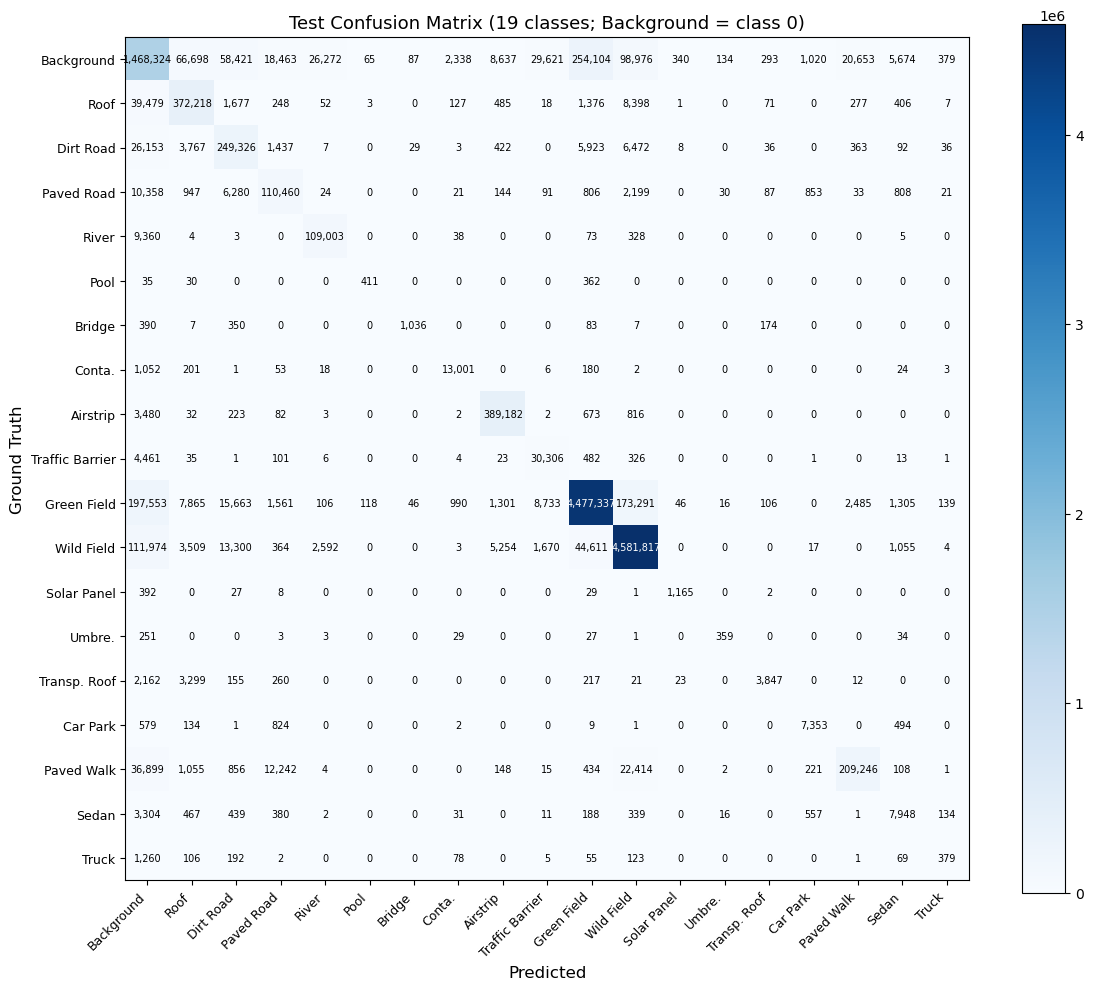

In [12]:
cm = test_m['confusion_matrix']
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Ground Truth', fontsize=12)
ax.set_title('Test Confusion Matrix (19 classes; Background = class 0)', fontsize=13)
thresh = cm.max() / 2.0
for r in range(NUM_CLASSES):
    for c in range(NUM_CLASSES):
        ax.text(c, r, f'{cm[r, c]:,}', ha='center', va='center',
                color='white' if cm[r, c] > thresh else 'black', fontsize=7)
plt.tight_layout(); plt.show()

## 9. Per-Class IoU Bar Chart


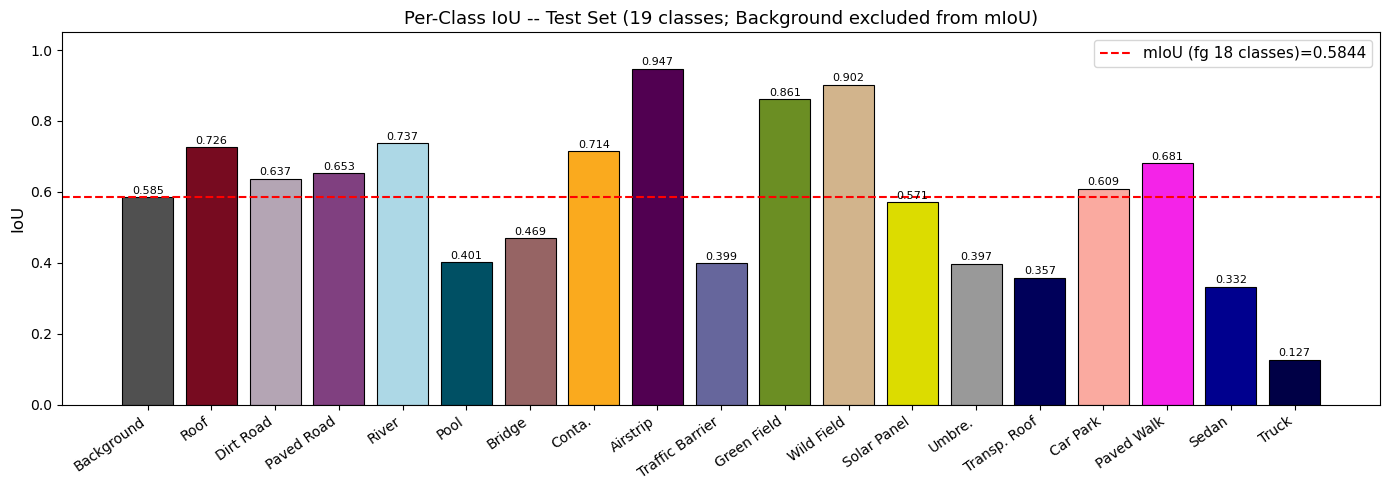

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, test_m['per_class_iou'],
              color=[PALETTE[i] for i in range(NUM_CLASSES)],
              edgecolor='black', linewidth=0.8)
ax.axhline(test_m['miou'], color='red', linestyle='--',
           label=f'mIoU (fg 18 classes)={test_m["miou"]:.4f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU', fontsize=12)
ax.set_title('Per-Class IoU -- Test Set (19 classes; Background excluded from mIoU)', fontsize=13)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
ax.legend(fontsize=11)
for bar, iou in zip(bars, test_m['per_class_iou']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{iou:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## 10. Qualitative Predictions (Dense Full-Cloud 100% Raw Points)

Visualizes the **entire raw LiDAR point cloud (~35,000+ points)** for a test scene in BEV:
- **Panel 1**: Dense Ground Truth (100% of points)
- **Panel 2**: Dense PMNet Model Prediction (100% of points)
- **Panel 3**: Camera FOV Coverage & Out-of-bounds Points


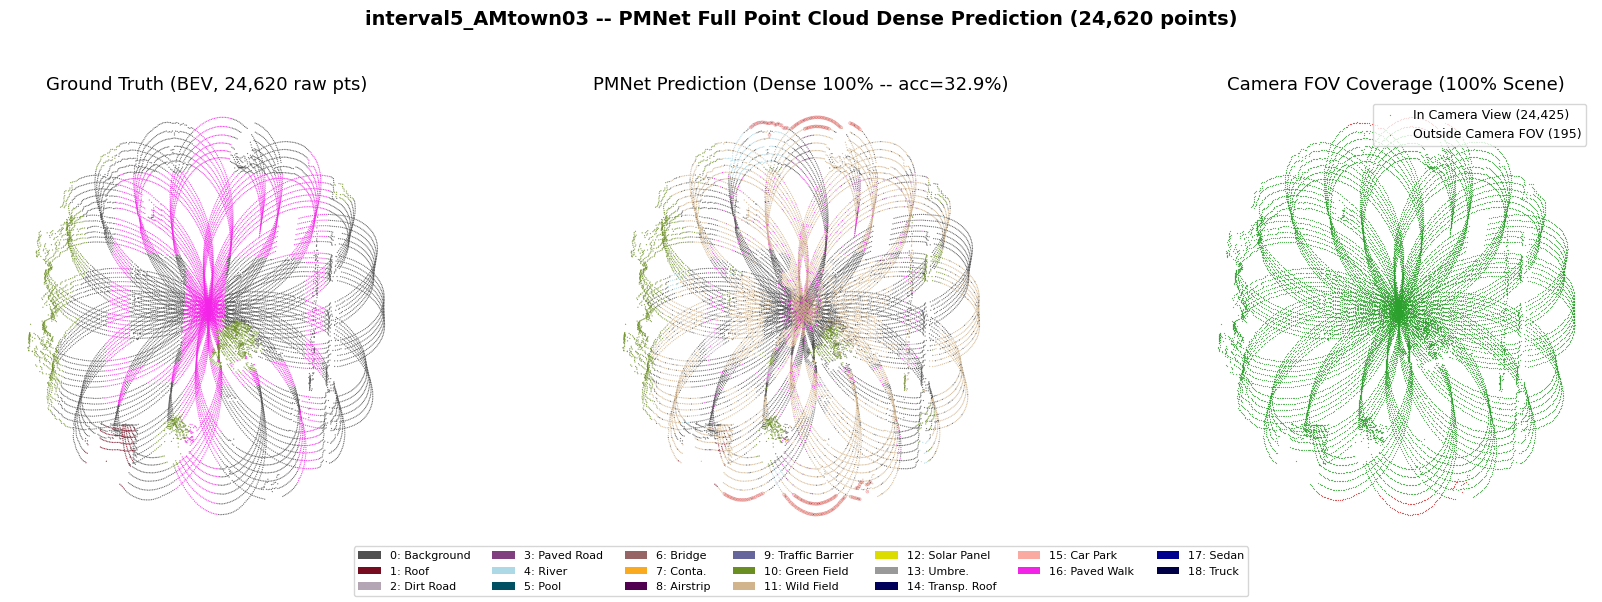

In [ ]:
# ---- Qualitative results: Dense Full-Cloud GT vs PMNet Prediction (100% raw points) ----
from data_utils import predict_full_pointcloud, get_calibration, map_labels_26_to_19, lidar_xyz_to_bev_coords
from PIL import Image
from matplotlib.patches import Patch

model.eval()
test_frame_idx = min(50, len(test_ds) - 1)
lidar_path, cam_path, label_path, seq_name = test_ds.frames[test_frame_idx]

# Load 100% of raw LiDAR points and raw labels for this frame
pts_raw = np.load(lidar_path).astype(np.float32)
pts_full = pts_raw[:, :3]
labels_26 = np.load(label_path).astype(np.int64)
labels_full = map_labels_26_to_19(labels_26)

with Image.open(cam_path) as img_pil:
    img_w, img_h = img_pil.size
    img_resized = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
img_norm = torch.from_numpy(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)

calib = get_calibration(seq_name)

# Run full-cloud dense inference (100% of points, no points skipped)
pred_full, all_logits_full, valid_fov = predict_full_pointcloud(
    model=model,
    pts_full=pts_full,
    img_tensor=img_norm,
    calib=calib,
    device=DEVICE,
    chunk_size=NUM_POINT,
    img_orig_size=(img_w, img_h),
    img_target_size=IMG_SIZE,
)

bev_full = lidar_xyz_to_bev_coords(pts_full)

def color_for(labels):
    c = np.zeros((len(labels), 3))
    ignore_mask = labels == IGNORE_INDEX
    c[~ignore_mask] = PALETTE[labels[~ignore_mask]]
    c[ignore_mask] = IGNORE_COLOR
    return c

valid_mask_eval = labels_full != IGNORE_INDEX
acc = (pred_full[valid_mask_eval] == labels_full[valid_mask_eval]).mean() * 100 if valid_mask_eval.any() else float('nan')

# Plot 100% of raw LiDAR points in BEV
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].scatter(bev_full[:, 0], bev_full[:, 1], c=color_for(labels_full), s=0.8, alpha=0.8, linewidths=0)
axes[0].set_title(f'Ground Truth (BEV, {len(pts_full):,} raw pts)', fontsize=13)
axes[0].set_aspect('equal'); axes[0].axis('off')

axes[1].scatter(bev_full[:, 0], bev_full[:, 1], c=color_for(pred_full), s=0.8, alpha=0.8, linewidths=0)
axes[1].set_title(f'PMNet Prediction (Dense 100% -- acc={acc:.1f}%)', fontsize=13)
axes[1].set_aspect('equal'); axes[1].axis('off')
axes[1].scatter(bev_full[~valid_fov, 0], bev_full[~valid_fov, 1], facecolors='none', edgecolors='tab:red', s=4.0, alpha=0.4, linewidths=0.5, label='Out-of-FOV Points')

axes[2].scatter(bev_full[valid_fov, 0], bev_full[valid_fov, 1], c='tab:green', s=0.8, alpha=0.8, label=f'In Camera View ({valid_fov.sum():,})', linewidths=0)
axes[2].scatter(bev_full[~valid_fov, 0], bev_full[~valid_fov, 1], c='tab:red', s=0.8, alpha=0.8, label=f'Outside Camera FOV ({(~valid_fov).sum():,})', linewidths=0)
axes[2].set_title('Camera FOV Coverage (100% Scene)', fontsize=13)
axes[2].set_aspect('equal'); axes[2].axis('off')
axes[2].legend(fontsize=9, loc='upper right')

legend_elements = [Patch(facecolor=PALETTE[i], label=f'{i}: {CLASS_NAMES[i]}') for i in range(NUM_CLASSES)]
fig.legend(handles=legend_elements, loc='lower center', ncol=7, fontsize=8)
plt.suptitle(f'{seq_name} -- PMNet Full Point Cloud Dense Prediction ({len(pts_full):,} points)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()


## 11. Test Split Global Macro-Tile Inference & Deduplicated .LAZ Export (Standalone)

**Completely Self-Contained Cell** — Can be run independently right after opening or reloading the notebook.

**Strict In-FOV Filtering + Zero-Downsampling Spatial Consensus + Location-Wise .LAZ Export**:
1. **Test Split Only**: Evaluates all 4 test locations (`AMtown03`, `AMvalley03`, `HKairport03`, `HKisland03`).
2. **Strict Camera-FOV Filtering**: Out-of-FOV points $(u, v) \notin [0, W) \times [0, H)$ are completely discarded.
3. **Dual Reference Frame Transformation**: Transforms local LiDAR coordinates to global absolute ENU world coordinates using 6-DoF trajectory poses.
4. **Spatial Deduplication with Majority Voting**: Merges overlapping camera views at the exact same physical coordinates ($2\text{ cm}$ threshold) by assigning the consensus majority class prediction with zero downsampling.
5. **Location-Wise `.LAZ` Export**: Exports a clean, colorized, 16-bit RGB `.laz` point cloud per test location.
6. **Comprehensive Benchmark Metrics**: Reports **Global mIoU** (18 foreground classes), **Overall Accuracy (OA)**, and per-class IoU summary across the test split.


In [1]:
# ==============================================================================
# STANDALONE CELL: Test Split In-FOV Inference, Spatial Deduplication & .LAZ
# (Evaluates all 4 test locations with strict in-FOV filtering & majority voting)
# ==============================================================================
import os, sys, json, time, subprocess
import numpy as np
import torch
from PIL import Image

# 0. Environment & Path Setup
THIS_DIR = os.path.abspath(os.getcwd())
if THIS_DIR not in sys.path:
    sys.path.insert(0, THIS_DIR)

# Auto-install / import laspy for .laz point cloud compression
try:
    import laspy
except ImportError:
    print('Installing laspy and lazrs compressor for .laz point cloud export...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'laspy[lazrs]'])
    import laspy

# Import local pipeline utilities and model
from data_utils import (
    predict_full_pointcloud,
    get_calibration,
    get_frame_list,
    map_labels_26_to_19,
    compute_metrics,
    CAM_LIDAR_DIR,
    PALETTE,
    CLASS_NAMES,
    NUM_CLASSES,
    IGNORE_INDEX,
)
from model_pmnet_torch import PMNet

# 1. Configuration: All 4 Test Split Locations
CKPT_PATH = '/mnt/d/Saqib/Multimodal_segmentation/PMNet_9class/checkpoints/pmnet_best.pth'
if not os.path.isfile(CKPT_PATH):
    CKPT_PATH = os.path.join(THIS_DIR, 'checkpoints', 'pmnet_best.pth')

TEST_SEQUENCES = [
    'interval5_AMtown03',
    'interval5_AMvalley03',
    'interval5_HKairport03',
    'interval5_HKisland03',
]

DEDUP_GRID_TOLERANCE = 0.02    # Spatial duplicate threshold in meters (2cm precision -- no downsampling)
MAX_FRAMES_PER_SEQ = None      # Set integer (e.g. 50) for fast preview, or None for full flights
IMG_SIZE = 256                 # PMNet 256x256 high-resolution camera input
CHUNK_INFERENCE_SIZE = 4096    # Point batch size for full-cloud GPU inference
OUT_DIR = os.path.join(THIS_DIR, 'global_tiles_output')
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True

# 2. Deduplication & Majority Voting Function
def deduplicate_by_majority_vote(pts_world, preds, confidences, targets, grid_tol=0.02):
    """
    Identifies spatial duplicates within `grid_tol` (e.g. 2cm) and takes the
    consensus majority vote for both predictions and ground truth.
    Preserves 100% of unique physical locations with zero downsampling.
    """
    grid_keys = np.round(pts_world / grid_tol).astype(np.int64)
    _, unique_indices, inverse_indices = np.unique(
        grid_keys, axis=0, return_index=True, return_inverse=True
    )
    n_unique = len(unique_indices)
    if n_unique == len(pts_world):
        return pts_world, preds, confidences, targets, 0
    
    counts = np.bincount(inverse_indices).astype(np.float32)
    n_duplicates_removed = len(pts_world) - n_unique
    
    # 1. Exact physical coordinate (mean of duplicate returns at that spot)
    pts_dedup = np.zeros((n_unique, 3), dtype=np.float32)
    np.add.at(pts_dedup, inverse_indices, pts_world)
    pts_dedup /= counts[:, None]
    
    # 2. Majority vote on predictions across overlapping views
    pred_votes = np.zeros((n_unique, NUM_CLASSES), dtype=np.int32)
    np.add.at(pred_votes, (inverse_indices, preds), 1)
    preds_dedup = np.argmax(pred_votes, axis=-1).astype(np.uint8)
    
    # 3. Averaged confidence
    conf_accum = np.zeros(n_unique, dtype=np.float32)
    np.add.at(conf_accum, inverse_indices, confidences)
    conf_dedup = (conf_accum / counts).astype(np.float32)
    
    # 4. Majority vote on ground truth targets
    valid_tgt_mask = (targets != IGNORE_INDEX) & (targets >= 0) & (targets < NUM_CLASSES)
    target_votes = np.zeros((n_unique, NUM_CLASSES), dtype=np.int32)
    np.add.at(target_votes, (inverse_indices[valid_tgt_mask], targets[valid_tgt_mask]), 1)
    
    has_valid_tgt = target_votes.sum(axis=-1) > 0
    targets_dedup = np.full(n_unique, IGNORE_INDEX, dtype=np.int8)
    targets_dedup[has_valid_tgt] = np.argmax(target_votes[has_valid_tgt], axis=-1).astype(np.int8)
    
    return pts_dedup, preds_dedup, conf_dedup, targets_dedup, n_duplicates_removed

# 3. Load Model & Trained Weights
print(f'\nLoading PMNet model weights from: {CKPT_PATH}')
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f'Checkpoint file not found: {CKPT_PATH}')

model = PMNet(num_classes=NUM_CLASSES, feature_num=3, dropout_rate=0.0).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    epoch_info = f" (Epoch {ckpt.get('epoch', '?')}, Val mIoU: {ckpt.get('val_miou', 0.0):.4f})"
elif isinstance(ckpt, dict) and 'state_dict' in ckpt:
    model.load_state_dict(ckpt['state_dict'])
    epoch_info = ''
else:
    model.load_state_dict(ckpt)
    epoch_info = ''
model.eval()
print(f'Model loaded successfully.{epoch_info}')

# 4. Iterate Over Test Locations: Filter In-FOV Only, Transform, and Deduplicate by Majority Vote
all_dedup_preds = []
all_dedup_targets = []
location_summaries = {}

t_total_start = time.time()
print(f'\n=== Starting Test Split In-FOV Evaluation & Deduplication ({len(TEST_SEQUENCES)} locations) ===')

with torch.no_grad():
    for seq_idx, seq_name in enumerate(TEST_SEQUENCES):
        print(f'\n' + '='*70)
        print(f'[{seq_idx+1}/{len(TEST_SEQUENCES)}] Processing Test Location (In-FOV Only): {seq_name}')
        print('='*70)
        
        pose_json_path = os.path.join(CAM_LIDAR_DIR, seq_name, 'sampleinfos_interpolated.json')
        if not os.path.isfile(pose_json_path):
            print(f'Warning: Trajectory pose file not found for {seq_name}, skipping.')
            continue
        
        with open(pose_json_path, 'r') as f:
            pose_data = json.load(f)
        pose_dict = {it.get('OriginalImageName', ''): np.array(it.get('T4x4', np.eye(4)), dtype=np.float64) for it in pose_data}
        
        frames = get_frame_list(seq_name)
        if MAX_FRAMES_PER_SEQ is not None:
            frames = frames[:MAX_FRAMES_PER_SEQ]
        print(f'Found {len(frames)} synchronized frames in {seq_name}.')
        
        calib = get_calibration(seq_name)
        R_ext = np.array(calib['camera_ext_R'], dtype=np.float64).reshape(3, 3)
        t_ext = np.array(calib['camera_ext_t'], dtype=np.float64).reshape(3, 1)
        
        seq_pts_world = []
        seq_preds = []
        seq_conf = []
        seq_targets = []
        
        total_raw_pts_count = 0
        total_infov_pts_count = 0
        
        t_seq_start = time.time()
        for f_idx, (lidar_path, cam_path, label_path, _) in enumerate(frames):
            cam_fname = os.path.basename(cam_path)
            if cam_fname not in pose_dict:
                continue
            T_cam_world = pose_dict[cam_fname]
            
            pts_raw = np.load(lidar_path).astype(np.float32)
            pts_lidar = pts_raw[:, :3]
            labels_raw = map_labels_26_to_19(np.load(label_path).astype(np.int64))
            total_raw_pts_count += len(pts_lidar)
            
            with Image.open(cam_path) as img_pil:
                img_w, img_h = img_pil.size
                img_resized = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
            img_tensor = torch.from_numpy(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)
            
            pred_labels, logits, valid_fov = predict_full_pointcloud(
                model=model,
                pts_full=pts_lidar,
                img_tensor=img_tensor,
                calib=calib,
                device=DEVICE,
                chunk_size=CHUNK_INFERENCE_SIZE,
                img_orig_size=(img_w, img_h),
                img_target_size=IMG_SIZE,
            )
            
            # STRICT FILTER: Discard all out-of-FOV points
            if not valid_fov.any():
                continue
            
            pts_lidar_fov = pts_lidar[valid_fov]
            pred_labels_fov = pred_labels[valid_fov]
            labels_raw_fov = labels_raw[valid_fov]
            logits_fov = logits[valid_fov]
            
            exp_logits = np.exp(logits_fov - np.max(logits_fov, axis=-1, keepdims=True))
            probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)
            confidence_fov = np.max(probs, axis=-1)
            
            # Transform strictly in-FOV points to Global World Frame
            pts_cam = (R_ext @ pts_lidar_fov.T.astype(np.float64) + t_ext).T
            pts_homo = np.hstack([pts_cam, np.ones((len(pts_cam), 1), dtype=np.float64)])
            pts_world_fov = (T_cam_world @ pts_homo.T).T[:, :3]
            
            total_infov_pts_count += len(pts_world_fov)
            seq_pts_world.append(pts_world_fov.astype(np.float32))
            seq_preds.append(pred_labels_fov.astype(np.uint8))
            seq_conf.append(confidence_fov.astype(np.float32))
            seq_targets.append(labels_raw_fov.astype(np.int8))
            
            if (f_idx + 1) % 50 == 0 or (f_idx + 1) == len(frames):
                elapsed = time.time() - t_seq_start
                cur_pts = sum(len(p) for p in seq_pts_world)
                print(f'  [{seq_name}] Frame {f_idx+1:4d}/{len(frames):4d} | In-FOV Points: {cur_pts:,d} ({elapsed:.1f}s)')
        
        raw_infov_pts = np.vstack(seq_pts_world)
        raw_infov_preds = np.concatenate(seq_preds)
        raw_infov_conf = np.concatenate(seq_conf)
        raw_infov_targets = np.concatenate(seq_targets)
        
        # Perform Majority-Voting Deduplication on Overlapping In-FOV Points
        print(f'\nApplying Spatial Deduplication on {len(raw_infov_pts):,d} In-FOV points...')
        pts_dedup, preds_dedup, conf_dedup, targets_dedup, n_dups = deduplicate_by_majority_vote(
            pts_world=raw_infov_pts,
            preds=raw_infov_preds,
            confidences=raw_infov_conf,
            targets=raw_infov_targets,
            grid_tol=DEDUP_GRID_TOLERANCE,
        )
        
        all_dedup_preds.append(preds_dedup)
        all_dedup_targets.append(targets_dedup)
        
        # Evaluate metrics strictly on deduplicated In-FOV points
        valid_eval_mask = (targets_dedup != IGNORE_INDEX) & (targets_dedup >= 0) & (targets_dedup < NUM_CLASSES)
        loc_metrics = compute_metrics(preds_dedup[valid_eval_mask], targets_dedup[valid_eval_mask], NUM_CLASSES, IGNORE_INDEX)
        
        fov_retention_pct = (total_infov_pts_count / max(total_raw_pts_count, 1)) * 100.0
        location_summaries[seq_name] = {
            'raw_points': total_raw_pts_count,
            'infov_points': len(raw_infov_pts),
            'unique_points': len(pts_dedup),
            'duplicates_voted': n_dups,
            'oa': loc_metrics['accuracy'] * 100.0,
            'miou': loc_metrics['miou'] * 100.0,
        }
        
        print(f'>> {seq_name} (In-FOV Deduplicated): {len(pts_dedup):,d} unique points (Resolved {n_dups:,d} overlaps via Majority Vote)')
        print(f'   OA = {loc_metrics["accuracy"]*100.0:.2f}% | mIoU (18 fg) = {loc_metrics["miou"]*100.0:.2f}%')
        
        # Export Location-Wise Deduplicated .LAZ Macro-Tile
        out_laz_path = os.path.join(OUT_DIR, f'{seq_name}_test_semantic_tile.laz')
        header = laspy.LasHeader(point_format=3, version='1.4')
        header.offsets = np.min(pts_dedup, axis=0)
        header.scales = np.array([0.001, 0.001, 0.001])
        
        all_colors = PALETTE[np.clip(preds_dedup, 0, NUM_CLASSES - 1)]
        las = laspy.LasData(header)
        las.x = pts_dedup[:, 0]
        las.y = pts_dedup[:, 1]
        las.z = pts_dedup[:, 2]
        las.classification = preds_dedup
        las.intensity = (conf_dedup * 255.0).astype(np.uint16)
        las.red = (all_colors[:, 0] * 65535.0).astype(np.uint16)
        las.green = (all_colors[:, 1] * 65535.0).astype(np.uint16)
        las.blue = (all_colors[:, 2] * 65535.0).astype(np.uint16)
        
        try:
            las.write(out_laz_path)
            print(f'   Saved Location-Wise .LAZ: {out_laz_path} ({os.path.getsize(out_laz_path)/(1024**2):.2f} MB)')
        except Exception as e:
            out_las = out_laz_path.replace('.laz', '.las')
            las.write(out_las)
            print(f'   Saved uncompressed .LAS: {out_las}')

# 5. Overall Combined Test Split Evaluation (Strictly In-FOV & Deduplicated Map)
total_test_preds = np.concatenate(all_dedup_preds)
total_test_targets = np.concatenate(all_dedup_targets)
valid_all = (total_test_targets != IGNORE_INDEX) & (total_test_targets >= 0) & (total_test_targets < NUM_CLASSES)
overall_metrics = compute_metrics(total_test_preds[valid_all], total_test_targets[valid_all], NUM_CLASSES, IGNORE_INDEX)

total_elapsed = time.time() - t_total_start
print('\n' + '='*75)
print('COMPLETE IN-FOV DEDUPLICATED TEST SPLIT EVALUATION (MAJORITY-VOTED MAP)')
print('='*75)
print(f'Total Unique Evaluated In-FOV Points: {len(total_test_preds):,d} (Time: {total_elapsed/60.0:.2f} min)')
print(f'Overall Accuracy (OA):                {overall_metrics["accuracy"]*100.0:6.2f}%')
print(f'Mean IoU (18 FG Classes):             {overall_metrics["miou"]*100.0:6.2f}%')
print('-' * 75)

print('Per-Location Summary (In-FOV Deduplicated & Majority-Voted):')
for seq, res in location_summaries.items():
    print(f'  {seq:<28s} | Unique In-FOV: {res["unique_points"]:10,d} (Resolved {res["duplicates_voted"]:8,d} overlaps) | OA: {res["oa"]:5.2f}% | mIoU: {res["miou"]:5.2f}%')
print('-' * 75)

print('Per-Class IoU across Entire Deduplicated In-FOV Test Map:')
hdr_id = 'Class ID'
hdr_name = 'Class Name'
hdr_iou = 'IoU (%)'
hdr_pts = 'Unique In-FOV Pts'
hdr_share = 'Share (%)'
print(f'{hdr_id:<10} | {hdr_name:<20} | {hdr_iou:<10} | {hdr_pts:<18} | {hdr_share:<10}')
print('-' * 75)
for c_idx in range(NUM_CLASSES):
    c_cnt = int((total_test_preds == c_idx).sum())
    c_pct = (c_cnt / len(total_test_preds)) * 100.0
    c_iou = overall_metrics['per_class_iou'][c_idx] * 100.0
    c_name = CLASS_NAMES[c_idx]
    print(f'{c_idx:<10d} | {c_name:<20s} | {c_iou:<9.2f}% | {c_cnt:<18,d} | {c_pct:<10.2f}%')
print('=' * 75)


Device: cuda
GPU:    NVIDIA RTX 4000 Ada Generation

Loading PMNet model weights from: /mnt/d/Saqib/Multimodal_segmentation/PMNet_9class/checkpoints/pmnet_best.pth
Model loaded successfully. (Epoch 80, Val mIoU: 0.0000)

=== Starting Test Split In-FOV Evaluation & Deduplication (4 locations) ===

[1/4] Processing Test Location (In-FOV Only): interval5_AMtown03
Found 1120 synchronized frames in interval5_AMtown03.
  [interval5_AMtown03] Frame   50/1120 | In-FOV Points: 1,219,848 (15.3s)
  [interval5_AMtown03] Frame  100/1120 | In-FOV Points: 2,458,696 (26.5s)
  [interval5_AMtown03] Frame  150/1120 | In-FOV Points: 3,661,744 (38.1s)
  [interval5_AMtown03] Frame  200/1120 | In-FOV Points: 4,861,318 (49.7s)
  [interval5_AMtown03] Frame  250/1120 | In-FOV Points: 6,012,841 (60.5s)
  [interval5_AMtown03] Frame  300/1120 | In-FOV Points: 7,201,272 (72.1s)
  [interval5_AMtown03] Frame  350/1120 | In-FOV Points: 8,411,220 (83.6s)
  [interval5_AMtown03] Frame  400/1120 | In-FOV Points: 9,597,633

## 12. Building-Specific Error Map & .LAZ Verification (Building vs. Rest)

Generates location-wise and combined test split point-cloud error maps evaluated with respect to the **Building** class (Roof + Transparent Roof) vs. Rest:
- **Green (Class 1)**: Building True Positive (Correct Building: `Target = Building`, `Pred = Building`)
- **Blue (Class 2)**: Building False Positive (Over-predicted Building: `Target != Building`, `Pred = Building`)
- **Red (Class 3)**: Building False Negative (Missed Building: `Target = Building`, `Pred != Building`)
- **Grey (Class 4)**: Non-Building / Background (`Target != Building`, `Pred != Building`)
- **Dark (Class 0)**: Ignored / Unlabeled points

In [ ]:
# ==============================================================================
# STANDALONE CELL: Building-Centric (Building vs. Rest) Error Analysis & .LAZ Export
# Categorization:
#   - GREEN (Class 1) : Building True Positive (Correctly identified building)
#   - BLUE  (Class 2) : Building False Positive (Non-building falsely predicted as building)
#   - RED   (Class 3) : Building False Negative (Real building missed by the model)
#   - GREY  (Class 4) : Rest of Scene / Non-Building points
# ==============================================================================
import os, sys, json, time, subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

# 0. Environment & Path Setup
THIS_DIR = os.path.abspath(os.getcwd())
if THIS_DIR not in sys.path:
    sys.path.insert(0, THIS_DIR)

try:
    import laspy
except ImportError:
    print('Installing laspy and lazrs compressor for .laz point cloud export...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'laspy[lazrs]'])
    import laspy

from data_utils import (
    predict_full_pointcloud,
    get_calibration,
    get_frame_list,
    map_labels_26_to_19,
    CAM_LIDAR_DIR,
    PALETTE,
    CLASS_NAMES,
    NUM_CLASSES,
    IGNORE_INDEX,
)
from model_pmnet_torch import PMNet

# 1. Configuration: All 4 Test Split Locations & Building Target Classes
CKPT_PATH = '/mnt/d/Saqib/Multimodal_segmentation/PMNet_9class/checkpoints/pmnet_best.pth'
if not os.path.isfile(CKPT_PATH):
    CKPT_PATH = os.path.join(THIS_DIR, 'checkpoints', 'pmnet_best.pth')

TEST_SEQUENCES = [
    'interval5_AMtown03',
    'interval5_AMvalley03',
    'interval5_HKairport03',
    'interval5_HKisland03',
]

# Building class definition in 19-class UAVScenes: 1 = Roof, 14 = Transparent Roof
BUILDING_CLASSES = [1, 14]
TARGET_LABEL_NAME = 'Building (Roof + Transp. Roof)'

DEDUP_GRID_TOLERANCE = 0.02    # Spatial duplicate threshold in meters (2cm precision)
MAX_FRAMES_PER_SEQ = None      # Set integer (e.g. 50) for fast preview, or None for full flights
IMG_SIZE = 256                 # PMNet 256x256 high-resolution camera input
CHUNK_INFERENCE_SIZE = 4096    # Point batch size for full-cloud GPU inference
OUT_DIR = os.path.join(THIS_DIR, 'global_tiles_output')
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True

# 2. Color Palette & Class ID Definitions (Building vs Rest)
COLOR_BLD_TP_NORM  = np.array([0.0, 1.0, 0.0], dtype=np.float32)       # Vibrant Green (Building Correct)
COLOR_BLD_TP_U16   = np.array([0, 65535, 0], dtype=np.uint16)

COLOR_BLD_FP_NORM  = np.array([0.0, 0.45, 1.0], dtype=np.float32)      # Electric Blue (Building False Positive)
COLOR_BLD_FP_U16   = np.array([0, 29491, 65535], dtype=np.uint16)

COLOR_BLD_FN_NORM  = np.array([1.0, 0.0, 0.0], dtype=np.float32)       # Vivid Red (Building False Negative)
COLOR_BLD_FN_U16   = np.array([65535, 0, 0], dtype=np.uint16)

COLOR_REST_NORM    = np.array([0.70, 0.70, 0.70], dtype=np.float32)    # Neutral Light Grey (Rest / Non-Building)
COLOR_REST_U16     = np.array([45875, 45875, 45875], dtype=np.uint16)

COLOR_IGN_NORM     = np.array([0.15, 0.15, 0.15], dtype=np.float32)    # Dark Charcoal (Ignored)
COLOR_IGN_U16      = np.array([9830, 9830, 9830], dtype=np.uint16)

# Error Classification Codes for LAS Classification Field
ERROR_CLASS_IGN     = 0  # Ignored / Unlabeled
ERROR_CLASS_BLD_TP  = 1  # Building True Positive (Correct) -> GREEN
ERROR_CLASS_BLD_FP  = 2  # Building False Positive (Over-predicted Building) -> BLUE
ERROR_CLASS_BLD_FN  = 3  # Building False Negative (Missed Building) -> RED
ERROR_CLASS_REST_TN = 4  # Non-Building / Background -> GREY

def classify_building_errors(preds, targets, building_classes=BUILDING_CLASSES):
    """
    Categorizes point-wise predictions with respect to the Building class vs. Rest into:
      - 1 (Green) : Building TP (Target = Building & Pred = Building)
      - 2 (Blue)  : Building FP (Target != Building & Pred = Building)
      - 3 (Red)   : Building FN (Target = Building & Pred != Building)
      - 4 (Grey)  : Non-Building (Target != Building & Pred != Building)
      - 0 (Dark)  : Ignored / Unlabeled (Target == IGNORE_INDEX or invalid)
    """
    n = len(preds)
    error_classes = np.zeros(n, dtype=np.uint8)
    
    valid_tgt = (targets != IGNORE_INDEX) & (targets >= 0) & (targets < NUM_CLASSES)
    
    is_tgt_bld = np.isin(targets, building_classes) & valid_tgt
    is_pred_bld = np.isin(preds, building_classes)
    
    # 1. Building True Positive (Green)
    tp_mask = valid_tgt & is_tgt_bld & is_pred_bld
    error_classes[tp_mask] = ERROR_CLASS_BLD_TP
    
    # 2. Building False Positive (Blue) -> Non-building misclassified as building
    fp_mask = valid_tgt & (~is_tgt_bld) & is_pred_bld
    error_classes[fp_mask] = ERROR_CLASS_BLD_FP
    
    # 3. Building False Negative (Red) -> Real building missed by the model
    fn_mask = valid_tgt & is_tgt_bld & (~is_pred_bld)
    error_classes[fn_mask] = ERROR_CLASS_BLD_FN
    
    # 4. Rest / Non-Building (Grey)
    rest_mask = valid_tgt & (~is_tgt_bld) & (~is_pred_bld)
    error_classes[rest_mask] = ERROR_CLASS_REST_TN
    
    return error_classes, valid_tgt

def deduplicate_by_majority_vote(pts_world, preds, confidences, targets, grid_tol=0.02):
    """
    Identifies spatial duplicates within `grid_tol` (e.g. 2cm) and takes the
    consensus majority vote for both predictions and ground truth.
    Preserves 100% of unique physical locations with zero downsampling.
    """
    grid_keys = np.round(pts_world / grid_tol).astype(np.int64)
    _, unique_indices, inverse_indices = np.unique(
        grid_keys, axis=0, return_index=True, return_inverse=True
    )
    n_unique = len(unique_indices)
    if n_unique == len(pts_world):
        return pts_world, preds, confidences, targets, 0
    
    counts = np.bincount(inverse_indices).astype(np.float32)
    n_duplicates_removed = len(pts_world) - n_unique
    
    # Coordinates
    pts_dedup = np.zeros((n_unique, 3), dtype=np.float32)
    np.add.at(pts_dedup, inverse_indices, pts_world)
    pts_dedup /= counts[:, None]
    
    # Prediction majority vote
    pred_votes = np.zeros((n_unique, NUM_CLASSES), dtype=np.int32)
    np.add.at(pred_votes, (inverse_indices, preds), 1)
    preds_dedup = np.argmax(pred_votes, axis=-1).astype(np.uint8)
    
    # Confidence
    conf_accum = np.zeros(n_unique, dtype=np.float32)
    np.add.at(conf_accum, inverse_indices, confidences)
    conf_dedup = (conf_accum / counts).astype(np.float32)
    
    # Ground truth majority vote
    valid_tgt_mask = (targets != IGNORE_INDEX) & (targets >= 0) & (targets < NUM_CLASSES)
    target_votes = np.zeros((n_unique, NUM_CLASSES), dtype=np.int32)
    np.add.at(target_votes, (inverse_indices[valid_tgt_mask], targets[valid_tgt_mask]), 1)
    
    has_valid_tgt = target_votes.sum(axis=-1) > 0
    targets_dedup = np.full(n_unique, IGNORE_INDEX, dtype=np.int8)
    targets_dedup[has_valid_tgt] = np.argmax(target_votes[has_valid_tgt], axis=-1).astype(np.int8)
    
    return pts_dedup, preds_dedup, conf_dedup, targets_dedup, n_duplicates_removed

# 3. Load Model Weights (Self-contained / Standalone)
print(f'\nLoading PMNet model weights from: {CKPT_PATH}')
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f'Checkpoint file not found: {CKPT_PATH}')

model = PMNet(num_classes=NUM_CLASSES, feature_num=3, dropout_rate=0.0).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    epoch_info = f" (Epoch {ckpt.get('epoch', '?')}, Val mIoU: {ckpt.get('val_miou', 0.0):.4f})"
elif isinstance(ckpt, dict) and 'state_dict' in ckpt:
    model.load_state_dict(ckpt['state_dict'])
    epoch_info = ''
else:
    model.load_state_dict(ckpt)
    epoch_info = ''
model.eval()
print(f'Model loaded successfully.{epoch_info}')

# 4. Process Each Test Location, Classify Building Errors & Export .LAZ
location_bld_summaries = {}
all_pts_list = []
all_preds_list = []
all_targets_list = []
all_err_classes_list = []
all_conf_list = []

t_total_start = time.time()
print(f'\n=== Starting Test Split Building Error Map Generation ({len(TEST_SEQUENCES)} locations) ===')
print(f'Target Concept: {TARGET_LABEL_NAME} (Classes: {BUILDING_CLASSES})')
print('Color Scheme: [GREEN] = Building TP | [BLUE] = Building FP | [RED] = Building FN | [GREY] = Rest of Scene')

with torch.no_grad():
    for seq_idx, seq_name in enumerate(TEST_SEQUENCES):
        print(f'\n' + '='*70)
        print(f'[{seq_idx+1}/{len(TEST_SEQUENCES)}] Processing Building Error Map: {seq_name}')
        print('='*70)
        
        pose_json_path = os.path.join(CAM_LIDAR_DIR, seq_name, 'sampleinfos_interpolated.json')
        if not os.path.isfile(pose_json_path):
            print(f'Warning: Trajectory pose file not found for {seq_name}, skipping.')
            continue
        
        with open(pose_json_path, 'r') as f:
            pose_data = json.load(f)
        pose_dict = {it.get('OriginalImageName', ''): np.array(it.get('T4x4', np.eye(4)), dtype=np.float64) for it in pose_data}
        
        frames = get_frame_list(seq_name)
        if MAX_FRAMES_PER_SEQ is not None:
            frames = frames[:MAX_FRAMES_PER_SEQ]
        print(f'Found {len(frames)} synchronized frames in {seq_name}.')
        
        calib = get_calibration(seq_name)
        R_ext = np.array(calib['camera_ext_R'], dtype=np.float64).reshape(3, 3)
        t_ext = np.array(calib['camera_ext_t'], dtype=np.float64).reshape(3, 1)
        
        seq_pts_world = []
        seq_preds = []
        seq_conf = []
        seq_targets = []
        
        t_seq_start = time.time()
        for f_idx, (lidar_path, cam_path, label_path, _) in enumerate(frames):
            cam_fname = os.path.basename(cam_path)
            if cam_fname not in pose_dict:
                continue
            T_cam_world = pose_dict[cam_fname]
            
            pts_raw = np.load(lidar_path).astype(np.float32)
            pts_lidar = pts_raw[:, :3]
            labels_raw = map_labels_26_to_19(np.load(label_path).astype(np.int64))
            
            with Image.open(cam_path) as img_pil:
                img_w, img_h = img_pil.size
                img_resized = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
            img_tensor = torch.from_numpy(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)
            
            pred_labels, logits, valid_fov = predict_full_pointcloud(
                model=model,
                pts_full=pts_lidar,
                img_tensor=img_tensor,
                calib=calib,
                device=DEVICE,
                chunk_size=CHUNK_INFERENCE_SIZE,
                img_orig_size=(img_w, img_h),
                img_target_size=IMG_SIZE,
            )
            
            if not valid_fov.any():
                continue
            
            pts_lidar_fov = pts_lidar[valid_fov]
            pred_labels_fov = pred_labels[valid_fov]
            labels_raw_fov = labels_raw[valid_fov]
            logits_fov = logits[valid_fov]
            
            exp_logits = np.exp(logits_fov - np.max(logits_fov, axis=-1, keepdims=True))
            probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)
            confidence_fov = np.max(probs, axis=-1)
            
            # Transform to Global World Frame
            pts_cam = (R_ext @ pts_lidar_fov.T.astype(np.float64) + t_ext).T
            pts_homo = np.hstack([pts_cam, np.ones((len(pts_cam), 1), dtype=np.float64)])
            pts_world_fov = (T_cam_world @ pts_homo.T).T[:, :3]
            
            seq_pts_world.append(pts_world_fov.astype(np.float32))
            seq_preds.append(pred_labels_fov.astype(np.uint8))
            seq_conf.append(confidence_fov.astype(np.float32))
            seq_targets.append(labels_raw_fov.astype(np.int8))
            
            if (f_idx + 1) % 50 == 0 or (f_idx + 1) == len(frames):
                elapsed = time.time() - t_seq_start
                cur_pts = sum(len(p) for p in seq_pts_world)
                print(f'  [{seq_name}] Frame {f_idx+1:4d}/{len(frames):4d} | In-FOV Points: {cur_pts:,d} ({elapsed:.1f}s)')
        
        raw_infov_pts = np.vstack(seq_pts_world)
        raw_infov_preds = np.concatenate(seq_preds)
        raw_infov_conf = np.concatenate(seq_conf)
        raw_infov_targets = np.concatenate(seq_targets)
        
        # Spatial Deduplication via Majority Voting
        print(f'\nApplying Spatial Deduplication on {len(raw_infov_pts):,d} In-FOV points...')
        pts_dedup, preds_dedup, conf_dedup, targets_dedup, n_dups = deduplicate_by_majority_vote(
            pts_world=raw_infov_pts,
            preds=raw_infov_preds,
            confidences=raw_infov_conf,
            targets=raw_infov_targets,
            grid_tol=DEDUP_GRID_TOLERANCE,
        )
        
        # Classify Building Errors (Green: TP | Blue: FP | Red: FN | Grey: Rest)
        error_classes, valid_mask = classify_building_errors(preds_dedup, targets_dedup, BUILDING_CLASSES)
        
        n_valid = int(valid_mask.sum())
        n_tp   = int((error_classes == ERROR_CLASS_BLD_TP).sum())
        n_fp   = int((error_classes == ERROR_CLASS_BLD_FP).sum())
        n_fn   = int((error_classes == ERROR_CLASS_BLD_FN).sum())
        n_rest = int((error_classes == ERROR_CLASS_REST_TN).sum())
        n_gt_bld = n_tp + n_fn
        n_pred_bld = n_tp + n_fp
        
        prec = (n_tp / max(n_pred_bld, 1)) * 100.0
        rec  = (n_tp / max(n_gt_bld, 1)) * 100.0
        iou  = (n_tp / max(n_tp + n_fp + n_fn, 1)) * 100.0
        f1   = (2 * prec * rec / max(prec + rec, 1e-6))
        
        location_bld_summaries[seq_name] = {
            'unique_points': len(pts_dedup),
            'valid_points': n_valid,
            'gt_buildings': n_gt_bld,
            'pred_buildings': n_pred_bld,
            'bld_tp': n_tp,
            'bld_fp': n_fp,
            'bld_fn': n_fn,
            'rest_pts': n_rest,
            'precision': prec,
            'recall': rec,
            'iou': iou,
            'f1': f1,
        }
        
        all_pts_list.append(pts_dedup)
        all_preds_list.append(preds_dedup)
        all_targets_list.append(targets_dedup)
        all_err_classes_list.append(error_classes)
        all_conf_list.append(conf_dedup)
        
        print(f'>> {seq_name} Building Verification ({n_gt_bld:,d} GT Building Points):')
        print(f'   - [GREEN] Building TP (Correct):  {n_tp:10,d} (Recall: {rec:5.2f}%)')
        print(f'   - [BLUE]  Building FP (False Pos):{n_fp:10,d} (Prec:   {prec:5.2f}%)')
        print(f'   - [RED]   Building FN (Missed):   {n_fn:10,d} (Missed: {100.0-rec:5.2f}%)')
        print(f'   - [GREY]  Rest of Scene (TN):     {n_rest:10,d}')
        print(f'   => Building IoU: {iou:5.2f}% | Building F1: {f1:5.2f}%')
        
        # Export Location-Wise Building Error .LAZ Macro-Tile
        out_err_laz_path = os.path.join(OUT_DIR, f'{seq_name}_building_error_tile.laz')
        header = laspy.LasHeader(point_format=3, version='1.4')
        header.offsets = np.min(pts_dedup, axis=0)
        header.scales = np.array([0.001, 0.001, 0.001])
        
        las_err = laspy.LasData(header)
        las_err.x = pts_dedup[:, 0]
        las_err.y = pts_dedup[:, 1]
        las_err.z = pts_dedup[:, 2]
        las_err.classification = error_classes
        las_err.intensity = (conf_dedup * 255.0).astype(np.uint16)
        
        r_u16 = np.zeros(len(pts_dedup), dtype=np.uint16)
        g_u16 = np.zeros(len(pts_dedup), dtype=np.uint16)
        b_u16 = np.zeros(len(pts_dedup), dtype=np.uint16)
        
        r_u16[error_classes == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[0]
        g_u16[error_classes == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[1]
        b_u16[error_classes == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[2]
        
        r_u16[error_classes == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[0]
        g_u16[error_classes == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[1]
        b_u16[error_classes == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[2]
        
        r_u16[error_classes == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[0]
        g_u16[error_classes == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[1]
        b_u16[error_classes == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[2]
        
        r_u16[error_classes == ERROR_CLASS_REST_TN] = COLOR_REST_U16[0]
        g_u16[error_classes == ERROR_CLASS_REST_TN] = COLOR_REST_U16[1]
        b_u16[error_classes == ERROR_CLASS_REST_TN] = COLOR_REST_U16[2]
        
        r_u16[error_classes == ERROR_CLASS_IGN] = COLOR_IGN_U16[0]
        g_u16[error_classes == ERROR_CLASS_IGN] = COLOR_IGN_U16[1]
        b_u16[error_classes == ERROR_CLASS_IGN] = COLOR_IGN_U16[2]
        
        las_err.red = r_u16
        las_err.green = g_u16
        las_err.blue = b_u16
        
        try:
            las_err.write(out_err_laz_path)
            print(f'   Saved Building Error .LAZ: {out_err_laz_path} ({os.path.getsize(out_err_laz_path)/(1024**2):.2f} MB)')
        except Exception as e:
            out_las = out_err_laz_path.replace('.laz', '.las')
            las_err.write(out_las)
            print(f'   Saved uncompressed Error Map .LAS: {out_las}')

# 5. Overall Combined Building Error Map & .LAZ Export
total_comb_pts = np.vstack(all_pts_list)
total_comb_preds = np.concatenate(all_preds_list)
total_comb_targets = np.concatenate(all_targets_list)
total_comb_err = np.concatenate(all_err_classes_list)
total_comb_conf = np.concatenate(all_conf_list)

tot_valid = (total_comb_err != ERROR_CLASS_IGN).sum()
tot_tp   = (total_comb_err == ERROR_CLASS_BLD_TP).sum()
tot_fp   = (total_comb_err == ERROR_CLASS_BLD_FP).sum()
tot_fn   = (total_comb_err == ERROR_CLASS_BLD_FN).sum()
tot_rest = (total_comb_err == ERROR_CLASS_REST_TN).sum()
tot_gt_bld = tot_tp + tot_fn
tot_pred_bld = tot_tp + tot_fp

tot_prec = (tot_tp / max(tot_pred_bld, 1)) * 100.0
tot_rec  = (tot_tp / max(tot_gt_bld, 1)) * 100.0
tot_iou  = (tot_tp / max(tot_tp + tot_fp + tot_fn, 1)) * 100.0
tot_f1   = (2 * tot_prec * tot_rec / max(tot_prec + tot_rec, 1e-6))

total_elapsed = time.time() - t_total_start
print('\n' + '='*75)
print('OVERALL TEST SPLIT BUILDING EVALUATION SUMMARY (BUILDING VS. REST)')
print('='*75)
print(f'Total Unique Evaluated Points:           {tot_valid:,d} (Elapsed: {total_elapsed/60.0:.2f} min)')
print(f'Total Ground Truth Building Points:      {tot_gt_bld:12,d}')
print(f'Total [GREEN] Building TP (Correct):     {tot_tp:12,d} (Recall:    {tot_rec:6.2f}%)')
print(f'Total [BLUE]  Building FP (False Pos):   {tot_fp:12,d} (Precision: {tot_prec:6.2f}%)')
print(f'Total [RED]   Building FN (Missed):      {tot_fn:12,d} (Miss Rate: {100.0-tot_rec:6.2f}%)')
print(f'Total [GREY]  Rest of Scene (Non-Bld):   {tot_rest:12,d}')
print('-' * 75)
print(f'Overall Building IoU:                    {tot_iou:6.2f}%')
print(f'Overall Building F1-Score:               {tot_f1:6.2f}%')
print('-' * 75)

print('Per-Location Building Summary Table:')
hdr_seq  = 'Location / Sequence'
hdr_gt   = 'GT Buildings'
hdr_tp   = 'TP (Green)'
hdr_fp   = 'FP (Blue)'
hdr_fn   = 'FN (Red)'
hdr_iou  = 'IoU (%)'
print(f'{hdr_seq:<24} | {hdr_gt:<12} | {hdr_tp:<14} | {hdr_fp:<14} | {hdr_fn:<14} | {hdr_iou:<8}')
print('-' * 80)
for seq, res in location_bld_summaries.items():
    seq_gt = res['gt_buildings']
    seq_tp = res['bld_tp']
    seq_fp = res['bld_fp']
    seq_fn = res['bld_fn']
    seq_iou = res['iou']
    print(f'{seq:<24s} | {seq_gt:12,d} | {seq_tp:14,d} | {seq_fp:14,d} | {seq_fn:14,d} | {seq_iou:7.2f}%')
print('=' * 80)

# Export Combined Global Building Error .LAZ
out_combined_laz = os.path.join(OUT_DIR, 'all_test_locations_building_error_map.laz')
header_comb = laspy.LasHeader(point_format=3, version='1.4')
header_comb.offsets = np.min(total_comb_pts, axis=0)
header_comb.scales = np.array([0.001, 0.001, 0.001])

las_comb = laspy.LasData(header_comb)
las_comb.x = total_comb_pts[:, 0]
las_comb.y = total_comb_pts[:, 1]
las_comb.z = total_comb_pts[:, 2]
las_comb.classification = total_comb_err
las_comb.intensity = (total_comb_conf * 255.0).astype(np.uint16)

r_comb = np.zeros(len(total_comb_pts), dtype=np.uint16)
g_comb = np.zeros(len(total_comb_pts), dtype=np.uint16)
b_comb = np.zeros(len(total_comb_pts), dtype=np.uint16)

r_comb[total_comb_err == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[0]
g_comb[total_comb_err == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[1]
b_comb[total_comb_err == ERROR_CLASS_BLD_TP] = COLOR_BLD_TP_U16[2]

r_comb[total_comb_err == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[0]
g_comb[total_comb_err == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[1]
b_comb[total_comb_err == ERROR_CLASS_BLD_FP] = COLOR_BLD_FP_U16[2]

r_comb[total_comb_err == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[0]
g_comb[total_comb_err == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[1]
b_comb[total_comb_err == ERROR_CLASS_BLD_FN] = COLOR_BLD_FN_U16[2]

r_comb[total_comb_err == ERROR_CLASS_REST_TN] = COLOR_REST_U16[0]
g_comb[total_comb_err == ERROR_CLASS_REST_TN] = COLOR_REST_U16[1]
b_comb[total_comb_err == ERROR_CLASS_REST_TN] = COLOR_REST_U16[2]

r_comb[total_comb_err == ERROR_CLASS_IGN] = COLOR_IGN_U16[0]
g_comb[total_comb_err == ERROR_CLASS_IGN] = COLOR_IGN_U16[1]
b_comb[total_comb_err == ERROR_CLASS_IGN] = COLOR_IGN_U16[2]

las_comb.red = r_comb
las_comb.green = g_comb
las_comb.blue = b_comb

try:
    las_comb.write(out_combined_laz)
    print(f'\nSaved Combined Building Error .LAZ: {out_combined_laz} ({os.path.getsize(out_combined_laz)/(1024**2):.2f} MB)')
except Exception as e:
    out_las = out_combined_laz.replace('.laz', '.las')
    las_comb.write(out_las)
    print(f'\nSaved Combined Building .LAS: {out_las}')

# 6. Qualitative Bird's-Eye-View (BEV) 3-Way Visualization
plot_seq_idx = 0
sample_pts = all_pts_list[plot_seq_idx]
sample_preds = all_preds_list[plot_seq_idx]
sample_targets = all_targets_list[plot_seq_idx]
sample_err = all_err_classes_list[plot_seq_idx]
sample_seq_name = TEST_SEQUENCES[plot_seq_idx]
sample_summary = location_bld_summaries[sample_seq_name]

max_plot_pts = 150000
if len(sample_pts) > max_plot_pts:
    step = len(sample_pts) // max_plot_pts
    sub_idx = np.arange(0, len(sample_pts), step)
else:
    sub_idx = np.arange(len(sample_pts))

p_pts = sample_pts[sub_idx]
p_preds = sample_preds[sub_idx]
p_targets = sample_targets[sub_idx]
p_err = sample_err[sub_idx]

# Ground truth binary building
gt_colors = np.zeros((len(p_pts), 3), dtype=np.float32)
is_bld_gt = np.isin(p_targets, BUILDING_CLASSES)
gt_colors[is_bld_gt] = PALETTE[1]
gt_colors[~is_bld_gt] = COLOR_REST_NORM

# Prediction binary building
pred_colors = np.zeros((len(p_pts), 3), dtype=np.float32)
is_bld_pred = np.isin(p_preds, BUILDING_CLASSES)
pred_colors[is_bld_pred] = PALETTE[1]
pred_colors[~is_bld_pred] = COLOR_REST_NORM

# Building Verification Error Map (Green: TP | Blue: FP | Red: FN | Grey: Rest)
err_colors = np.zeros((len(p_pts), 3), dtype=np.float32)
err_colors[p_err == ERROR_CLASS_BLD_TP]  = COLOR_BLD_TP_NORM
err_colors[p_err == ERROR_CLASS_BLD_FP]  = COLOR_BLD_FP_NORM
err_colors[p_err == ERROR_CLASS_BLD_FN]  = COLOR_BLD_FN_NORM
err_colors[p_err == ERROR_CLASS_REST_TN] = COLOR_REST_NORM
err_colors[p_err == ERROR_CLASS_IGN]     = COLOR_IGN_NORM

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

axes[0].scatter(p_pts[:, 0], p_pts[:, 1], c=gt_colors, s=1.0, alpha=0.85, linewidths=0)
axes[0].set_title(f'1. Ground Truth Buildings\n({sample_seq_name})', fontsize=12, fontweight='bold')
axes[0].set_aspect('equal'); axes[0].axis('off')

axes[1].scatter(p_pts[:, 0], p_pts[:, 1], c=pred_colors, s=1.0, alpha=0.85, linewidths=0)
plot_iou = sample_summary['iou']
axes[1].set_title(f'2. Predicted Buildings\n(Building IoU = {plot_iou:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_aspect('equal'); axes[1].axis('off')

axes[2].scatter(p_pts[:, 0], p_pts[:, 1], c=err_colors, s=1.0, alpha=0.85, linewidths=0)
axes[2].set_title(f'3. Building Error Map\n(Green: TP | Blue: FP | Red: FN | Grey: Rest)', fontsize=12, fontweight='bold')
axes[2].set_aspect('equal'); axes[2].axis('off')

lbl_tp = sample_summary['bld_tp']
lbl_fp = sample_summary['bld_fp']
lbl_fn = sample_summary['bld_fn']
lbl_rest = sample_summary['rest_pts']

legend_elements = [
    Patch(facecolor=COLOR_BLD_TP_NORM, edgecolor='black', label=f'Building TP (Green): {lbl_tp:,d}'),
    Patch(facecolor=COLOR_BLD_FP_NORM, edgecolor='black', label=f'Building FP (Blue):  {lbl_fp:,d}'),
    Patch(facecolor=COLOR_BLD_FN_NORM, edgecolor='black', label=f'Building FN (Red):   {lbl_fn:,d}'),
    Patch(facecolor=COLOR_REST_NORM, edgecolor='black',   label=f'Rest of Scene (Grey):{lbl_rest:,d}'),
]
axes[2].legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

plt.suptitle(f'Building-Centric Verification & Error Analysis — {sample_seq_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
